In [1]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] "brazilian-ecommerce"    "marketing-funnel-olist"

# 1. Import packages and load dataset

In [2]:
library(readr)
library(dplyr)
# To shut off warnings
options(warn=-1)
# Loading libraries
if (!require(tictoc)) install.packages("tictoc")
if (!require(glue)) install.packages("glue")
if (!require(ggplot2)) install.packages(ggplot2)
sh <- suppressPackageStartupMessages
sh(library('tictoc'))
sh(library("glue"))
sh(library('dplyr'))

Loading required package: tictoc

Loading required package: glue



In [3]:
# Having a static random seed so that we get the same results for the whole script everytime
set.seed(42)
tic("Data loading")
qualified_leads_df <- read.csv("/kaggle/input/marketing-funnel-olist/olist_marketing_qualified_leads_dataset.csv", header=TRUE)
print(glue("The first five rows of data are as follows"))
head(qualified_leads_df, n=5)
toc()
print(glue("Shape of dataset is {nrow(qualified_leads_df)} rows and {ncol(qualified_leads_df)} columns"))
summary(qualified_leads_df)

The first five rows of data are as follows


,mql_id,first_contact_date,landing_page_id,origin
,<chr>,<chr>,<chr>,<chr>
1,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social
2,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search
3,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search
4,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email
5,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search


Data loading: 0.061 sec elapsed
Shape of dataset is 8000 rows and 4 columns


    mql_id          first_contact_date landing_page_id       origin         
 Length:8000        Length:8000        Length:8000        Length:8000       
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  

In [4]:
tic("Data loading")
closed_deals_df <- read.csv("/kaggle/input/marketing-funnel-olist/olist_closed_deals_dataset.csv", header=TRUE)
print(glue("The first five rows of data are as follows"))
head(closed_deals_df, n=5)
toc()
print(glue("Shape of dataset is {nrow(closed_deals_df)} rows and {ncol(closed_deals_df)} columns"))
summary(closed_deals_df)

The first five rows of data are as follows


,mql_id,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,cat,,,,reseller,NA,0
2,a555fb36b9368110ede0f043dfc3b9a0,bbb7d7893a450660432ea6652310ebb7,09285259593c61296eef10c734121d5b,d3d1e91a157ea7f90548eef82f1955e3,2018-05-08 20:17:59,car_accessories,industry,eagle,,,,reseller,NA,0
3,327174d3648a2d047e8940d7d15204ca,612170e34b97004b3ba37eae81836b4c,b90f87164b5f8c2cfa5c8572834dbe3f,6565aa9ce3178a5caf6171827af3a9ba,2018-06-05 17:27:23,home_appliances,online_big,cat,,,,reseller,NA,0
4,f5fee8f7da74f4887f5bcae2bafb6dd6,21e1781e36faf92725dde4730a88ca0f,56bf83c4bb35763a51c2baab501b4c67,d3d1e91a157ea7f90548eef82f1955e3,2018-01-17 13:51:03,food_drink,online_small,,,,,reseller,NA,0
5,ffe640179b554e295c167a2f6be528e0,ed8cb7b190ceb6067227478e48cf8dde,4b339f9567d060bcea4f5136b9f5949e,d3d1e91a157ea7f90548eef82f1955e3,2018-07-03 20:17:45,home_appliances,industry,wolf,,,,manufacturer,NA,0


Data loading: 0.034 sec elapsed
Shape of dataset is 842 rows and 14 columns


    mql_id           seller_id            sdr_id             sr_id          
 Length:842         Length:842         Length:842         Length:842        
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
                                                                            
   won_date         business_segment    lead_type        
 Length:842         Length:842         Length:842        
 Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character  
                                                         
                                                         
                                    

# 2. Explore dataset separately

In [5]:
sorted_leadtypes = closed_deals_df %>% group_by(lead_type) %>% summarise(Count = n()) %>% arrange(desc(Count))
sorted_leadtypes

lead_type,Count
<chr>,<int>
online_medium,332
online_big,126
industry,123
offline,104
online_small,77
online_beginner,57
online_top,14
,6
other,3


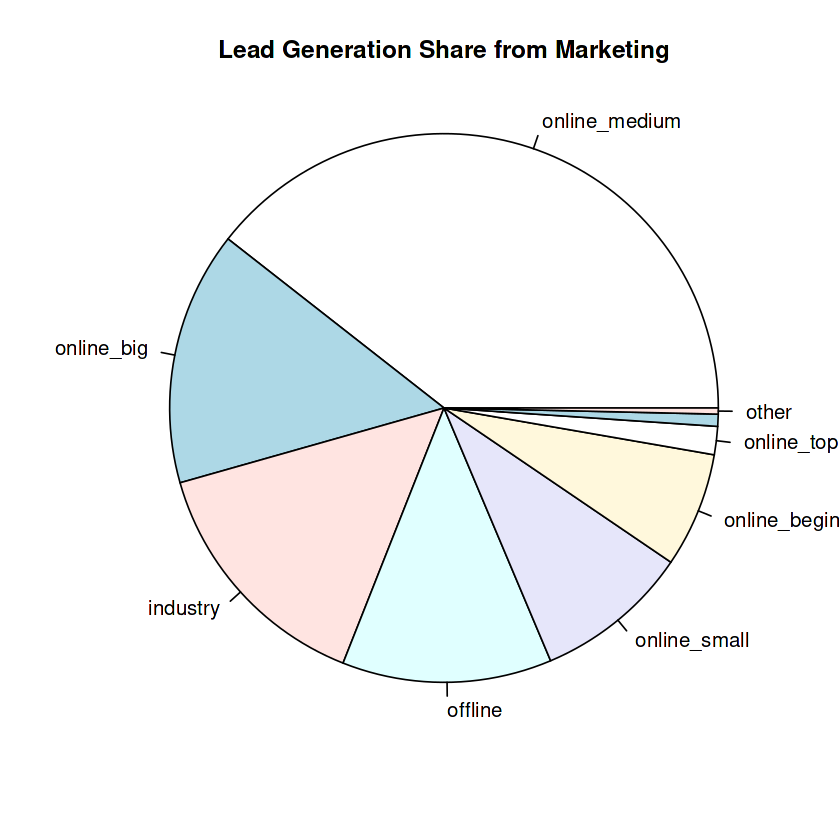

In [6]:
pie(sorted_leadtypes$Count, sorted_leadtypes$lead_type, main='Lead Generation Share from Marketing',radius=2)

##### Clearly online medium is the clear winner and more marketing funds should be denoted towards that.

In [7]:
sorted_businesstypes = closed_deals_df %>% group_by(business_type) %>% summarise(Count = n()) %>% arrange(desc(Count))
sorted_businesstypes

business_type,Count
<chr>,<int>
reseller,587
manufacturer,242
,10
other,3


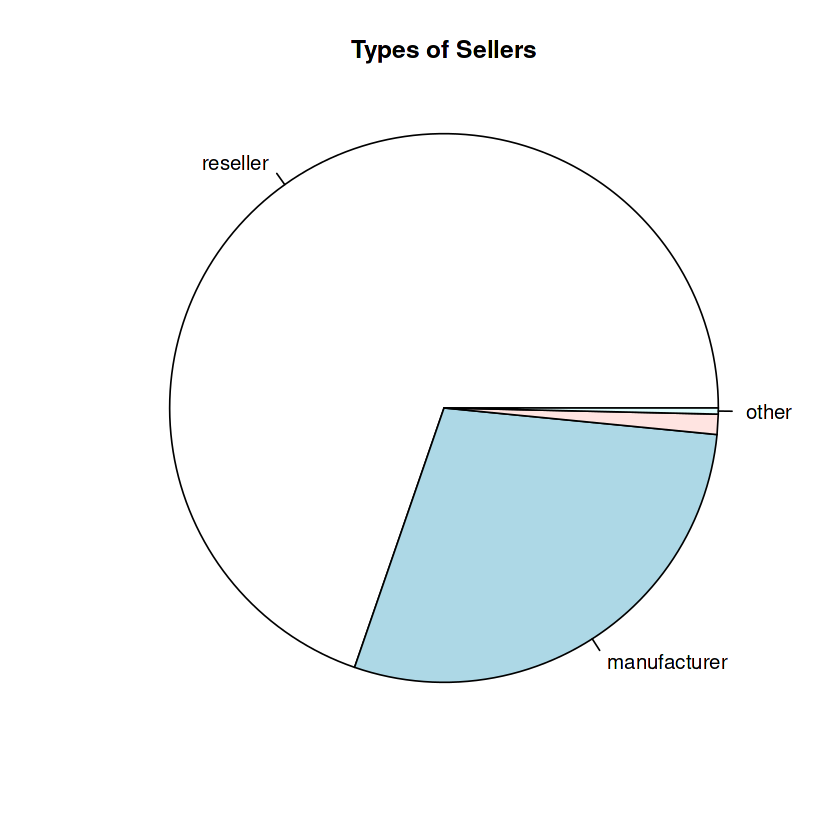

In [8]:
pie(sorted_businesstypes$Count, sorted_businesstypes$business_type, main='Types of Sellers',radius=2)

##### We see that the majority percentage is mostly resellers. More marketing should be directed towards manufacturers - plans of direct partnership with manufacturers for higher profit margins.

In [9]:
sorted_origins = qualified_leads_df %>% group_by(origin) %>% summarise(Count = n()) %>% arrange(desc(Count))
sorted_origins

origin,Count
<chr>,<int>
organic_search,2296
paid_search,1586
social,1350
unknown,1099
direct_traffic,499
email,493
referral,284
other,150
display,118


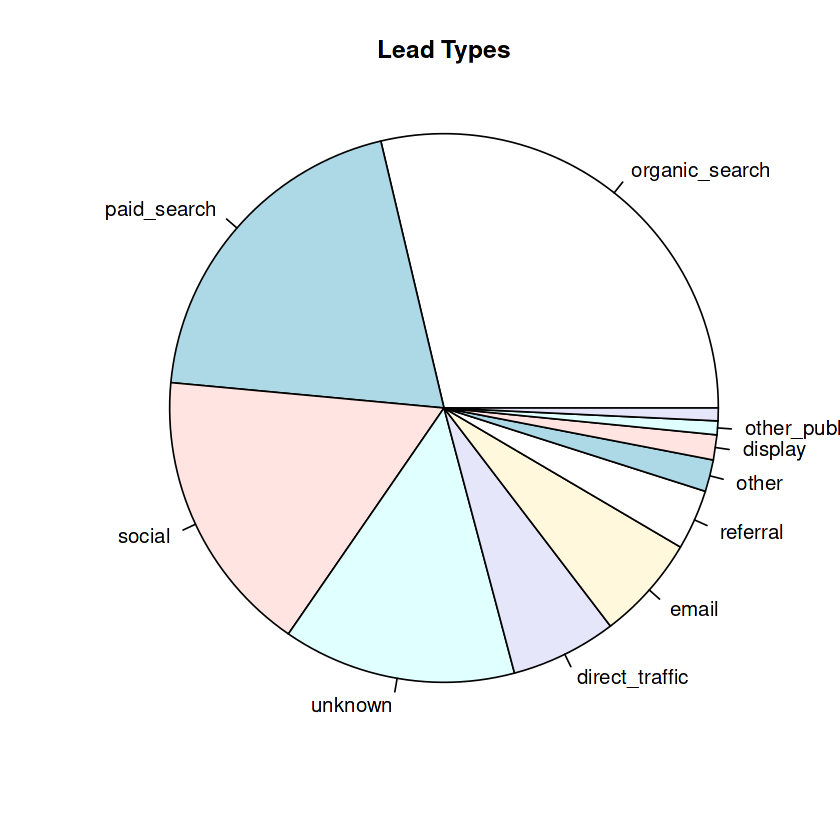

In [10]:
pie(sorted_origins$Count, sorted_origins$origin, main='Lead Types', radius=2)

A lot of the leads are generated by organic search, which means there is a enuine demand for sellers to sell on the website. One interesting observation is referral is quite low. This might be a insight into psychology that sellers do not want competetion, thus they are hesitant to refer other sellers to the website. A better referral program which has more incentive might be put out to bring in more leads through the referral channel. We also see a big chunk to unknown, we need to track the leads better. Furthermore, we should spend more budget on paid searches and social media because they are the highest performers, instead of channels like display or emails.


# 3. Combine 2 datasets

I am combine the [other dataset from Olist](https://www.kaggle.com/code/ngantran76/how-does-delivery-time-affect-customers-ratings) to analyze the links and effectiveness of their marketing funnels on sales. 

In [11]:
# Load Olist Marketing funnel datasets
leads <-read.csv("/kaggle/input/marketing-funnel-olist/olist_marketing_qualified_leads_dataset.csv" )
closed <-read.csv("/kaggle/input/marketing-funnel-olist/olist_closed_deals_dataset.csv")

# Merge Marketing funnel datasets into one
mkt_data <- merge(leads, closed,by="mql_id")

# Getting an idea of total number of unique sellers listed in these datasets
length(unique(mkt_data$seller_id))
dim(mkt_data)
head(mkt_data)

# Load Olist Order and Sales datasets
geolocations <- read_csv("/kaggle/input/brazilian-ecommerce/olist_geolocation_dataset.csv")
customers <- read_csv("/kaggle/input/brazilian-ecommerce/olist_customers_dataset.csv")
items <- read_csv("/kaggle/input/brazilian-ecommerce/olist_order_items_dataset.csv")
reviews <- read_csv("/kaggle/input/brazilian-ecommerce/olist_order_reviews_dataset.csv")
products <- read_csv("/kaggle/input/brazilian-ecommerce//olist_products_dataset.csv")
sellers <- read_csv("/kaggle/input/brazilian-ecommerce/olist_sellers_dataset.csv")
payments <- read_csv("/kaggle/input/brazilian-ecommerce/olist_order_payments_dataset.csv")
orders <- read_csv("/kaggle/input/brazilian-ecommerce/olist_orders_dataset.csv")

[1] 842

[1] 842  17

,mql_id,first_contact_date,landing_page_id,origin,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,000dd3543ac84d906eae52e7c779bb2a,2018-04-05,b48ec5f3b04e9068441002a19df93c6c,organic_search,500b5e25308adf85bbc0bbc52c3dc05b,a8387c01a09e99ce014107505b92388c,9e4d1098a3b0f5da39b0bc48f9876645,2018-04-24 03:00:00,home_decor,industry,cat,,,,manufacturer,NA,0
2,009ff90f082aaa9fcd6e14caf65c7cc6,2018-03-19,4aab772aeb9833c170d8ea5413e02eac,paid_search,134285d1f41da5c13a756ee8142c8a4e,a8387c01a09e99ce014107505b92388c,9e4d1098a3b0f5da39b0bc48f9876645,2018-04-03 03:00:00,car_accessories,online_big,cat,,,,reseller,NA,0
3,00dc5000951c268cc8655294daf67b1b,2018-03-26,282cb66cf00adbf96a4486eb4cb2431c,paid_search,00065220becb8785e2cf78355eb9bf68,9d12ef1a7eca3ec58c545c678af7869c,de63de0d10a6012430098db33c679b0b,2018-07-10 11:34:50,handcrafted,online_medium,cat,False,False,20-50,reseller,NA,0
4,010ed37e44e2fdc175b4c5c6c930805a,2018-03-06,b6885f18d203a61176418c1fb3764815,paid_search,8c6d188ef073e289887bc52bc37f3e61,068066e24f0c643eb1d089c7dd20cd73,9749123c950bf8363ace42cb1c2d0815,2018-09-14 14:43:50,audio_video_electronics,online_medium,cat,True,True,5-20,reseller,70,250000
5,012fa44d6752ee07c167165cb8c6f11c,2018-03-07,22c29808c4f815213303f8933030604c,unknown,528e4514f9339c1c3dd7535fd1a2d8cb,9e4d1098a3b0f5da39b0bc48f9876645,4ef15afb4b2723d8f3d81e51ec7afefe,2018-03-08 15:01:48,home_decor,online_small,wolf,,,,manufacturer,NA,0
6,01409f7f7f2bd5ec0c1755b362e9db6e,2018-01-30,21a104c3279681d9856b8a48723c4fee,other_publicities,eada4a0629faf243de4159916c10cd1a,fdb16d3cbbeb5798f2f66c4096be026d,2695de1affa7750089c0455f8ce27021,2018-03-06 18:14:08,health_beauty,online_big,cat,,,,reseller,NA,0


Rows: 1000163 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): geolocation_zip_code_prefix, geolocation_city, geolocation_state
dbl (2): geolocation_lat, geolocation_lng

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 99441 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): customer_id, customer_unique_id, customer_zip_code_prefix, customer...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 112650 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): order_id, product_id, seller_id
dbl  (3): order_item_id, price, freight_value
dttm (1): shipping_limit_date

ℹ Use `spec()` 

This **new** dataset only contains information about 842 sellers.

In [12]:
# Merging all the Olist order and sales datasets into one df
# https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
temp <-orders %>%
     left_join(payments) %>%
     left_join(items) %>%
     #left_join(distinct(select(items, order_id, seller_id))) %>%
     left_join(customers) %>%
     left_join(distinct(select(reviews, order_id))) %>%
     left_join(sellers) %>%
     distinct(order_id, .keep_all = TRUE) %>%
     group_by(order_id)

dim(temp)

# Adding in the marketing data sets found here that were already prepared in code cell code above:
# https://www.kaggle.com/datasets/olistbr/marketing-funnel-olist
temp2 <- temp %>%
    left_join(mkt_data) %>%
    distinct(seller_id, .keep_all = TRUE) %>%
    # Dropping all rows with NA values that will not be useful for our analysis
    # These represent orders fulfilled by sellers that don't have a match in the Marketing Funnel dataset
    filter(!is.na(mql_id)) %>%
    group_by(seller_id)

dim(temp2)
# Adjust IPython display options to show more columns
options(repr.matrix.max.cols=150, repr.matrix.max.rows=200)

head(temp2)

#summary(temp2)
sapply(temp2, function(x) sum(is.na(x)))

Joining with `by = join_by(order_id)`
Joining with `by = join_by(order_id)`
Joining with `by = join_by(customer_id)`
Joining with `by = join_by(order_id)`
Joining with `by = join_by(seller_id)`


[1] 99441    25

Joining with `by = join_by(seller_id)`


[1] 4466   41

order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,mql_id,first_contact_date,landing_page_id,origin,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
<chr>,<chr>,<chr>,<dttm>,<dttm>,<dttm>,<dttm>,<dttm>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dttm>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
82566a660a982b15fb86e904c8d32918,d3e3b74c766bc6214e0c830b17ee2341,delivered,2018-06-07 10:06:19,2018-06-09 03:13:12,2018-06-11 13:29:00,2018-06-19 12:05:52,2018-07-18,1,boleto,1,50.13,1,72a97c271b2e429974398f46b93ae530,094ced053e257ae8cae57205592d6712,2018-06-18 03:13:12,31.90,18.23,e97109680b052ee858d93a539597bba7,35400,ouro preto,MG,14095,ribeirao preto,SP,62a081b993506561f522af260073cb18,2018-03-02,4e24f6443807ad2eba56754b0dc91140,direct_traffic,9e4d1098a3b0f5da39b0bc48f9876645,4ef15afb4b2723d8f3d81e51ec7afefe,2018-03-13 12:33:10,health_beauty,online_medium,cat,,,,reseller,NA,0
dcb36b511fcac050b97cd5c05de84dc3,3b6828a50ffe546942b7a473d70ac0fc,delivered,2018-06-07 19:03:12,2018-06-12 23:31:02,2018-06-11 14:54:00,2018-06-21 15:34:32,2018-07-04,1,credit_card,10,146.45,1,009c09f439988bc06a93d6b8186dce73,89a51f50b8095ea78d5768f34c13a76f,2018-06-18 18:59:02,132.40,14.05,ccafc1c3f270410521c3c6f3b249870f,74820,goiania,GO,71931,brasilia,DF,7c3e1a45e4127c0eb25d7a8b7250da5b,2017-08-30,fbc24da54d531c6204ae2d17b1090bb1,paid_search,068066e24f0c643eb1d089c7dd20cd73,060c0a26f19f4d66b42e0d8796688490,2018-04-10 19:17:03,health_beauty,online_small,,,,,reseller,NA,0
f3e7c359154d965827355f39d6b1fdac,62b423aab58096ca514ba6aa06be2f98,delivered,2018-08-09 11:44:40,2018-08-10 03:24:51,2018-08-10 12:29:00,2018-08-13 18:24:27,2018-08-17,1,boleto,1,104.11,1,e99d69efe684efaa643f99805f7c81bc,55c26bcb609f480eb7868594245febb5,2018-08-14 03:24:51,89.90,14.21,9c9242ad7f1b52d926ea76778e1c0c57,18052,sorocaba,SP,14910,tabatinga,SP,f74b25a7dc1504cf5a3b964a990266ff,2018-01-19,b76ef37428e6799c421989521c0e5077,organic_search,56bf83c4bb35763a51c2baab501b4c67,d3d1e91a157ea7f90548eef82f1955e3,2018-03-01 14:58:45,baby,online_big,cat,,,,reseller,NA,0
91b2a010e1e45e6ba3d133fa997597be,cce89a605105b148387c52e286ac8335,delivered,2018-05-02 11:45:38,2018-05-03 12:55:01,2018-05-10 16:16:00,2018-05-16 20:56:24,2018-05-23,1,credit_card,8,192.68,1,ba74c6b75d2ad7503175809688d5a03c,7d13fca15225358621be4086e1eb0964,2018-05-09 12:55:01,178.99,13.69,bd13608b9c6033892ce62269b50a0afc,09182,santo andre,SP,14050,ribeirao preto,SP,0b97be8b4b408a3a0780a32e0a143a7f,2018-01-22,b76ef37428e6799c421989521c0e5077,unknown,56bf83c4bb35763a51c2baab501b4c67,9ae085775a198122c5586fa830ff7f2b,2018-02-08 17:20:14,watches,online_big,,,,,reseller,NA,0
d22e9fa5731b9e30e8b27afcdc2f8563,756fb9391752dad934e0fe3733378e57,delivered,2018-08-04 23:25:30,2018-08-04 23:35:13,2018-08-06 15:03:00,2018-08-13 23:34:42,2018-09-13,1,debit_card,1,121.62,1,f410090aec61f7c73748ca894286edcd,980640c45d7a4635885491d077167e4d,2018-08-07 23:35:13,99.00,22.62,394b2ce444baae9ae609f5d32000de0f,47850,luis eduardo magalhaes,BA,13501,rio claro,SP,68482ad368c7b9779cf50a7164815379,2018-05-22,b76ef37428e6799c421989521c0e5077,unknown,4b339f9567d060bcea4f5136b9f5949e,de63de0d10a6012430098db33c679b0b,2018-05-24 20:25:11,bags_backpacks,online_medium,cat,,,,reseller,NA,0
47aa4816b27ba60ec948cd019cc1afc1,148348ff65384b4249b762579532e248,delivered,2018-06-26 13:42:52,2018-06-27 08:35:32,2018-06-27 13:20:00,2018-07-03 18:37:46,2018-07-20,1,boleto,1,71.91,1

order_id                   customer_id 
                            0                             0 
                 order_status      order_purchase_timestamp 
                            0                             0 
            order_approved_at  order_delivered_carrier_date 
                            0                            14 
order_delivered_customer_date order_estimated_delivery_date 
                           57                             0 
           payment_sequential                  payment_type 
                            0                             0 
         payment_installments                 payment_value 
                            0                             0 
                order_item_id                    product_id 
                            0                             0 
                    seller_id           shipping_limit_date 
                            0                             0 
                        price                 freight_value 
                            0                             0 
           customer_unique_id      customer_zip_code_prefix 
                            0                             0 
                customer_city                customer_state 
                            0                             0 
       seller_zip_code_prefix                   seller_city 
                            0                             0 
                 seller_state                        mql_id 
                            0                             0 
           first_contact_date               landing_page_id 
                            0                             0 
                       origin                        sdr_id 
                            0                             0 
                        sr_id                      won_date 
                            0                             0 
             business_segment                     lead_type 
                            0                             0 
       lead_behaviour_profile                   has_company 
                            0                             0 
                     has_gtin                 average_stock 
                            0                             0 
                business_type declared_product_catalog_size 
                            0                          4466 
     declared_monthly_revenue 
                            0

In [13]:
# Adding some auxilary columns and removing column full of NA values
temp3 <- temp2 %>%
    # Creating indicator column that shows whether delivery was made on time
    mutate(delivered_on_time=ifelse((order_delivered_customer_date <= order_estimated_delivery_date) & !is.na(order_delivered_customer_date) , 1, 0)) %>%
    # Creating indicator column that shows whether shipment was completed on time
    mutate(shipped_on_time=ifelse((order_delivered_carrier_date <= shipping_limit_date) & !is.na(order_delivered_carrier_date), 1, 0)) %>%
    # Add shipping time column (how many days it took between order and delivery)
    mutate(delivery_time = round(as.numeric(difftime(order_delivered_customer_date, order_purchase_timestamp, units ="days")),2)) %>%
    # Add duration column (how many days between first contact to close for each lead)
    mutate(lead_to_close = round(as.numeric(difftime(won_date, first_contact_date, units ="days")),2)) %>%
    # Removing useless column that is full of NA values above
    select(-declared_product_catalog_size)

head(temp3)
# Checking NA values
#sapply(temp3, function(x) sum(is.na(x)))
dim(temp3)

order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,mql_id,first_contact_date,landing_page_id,origin,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_monthly_revenue,delivered_on_time,shipped_on_time,delivery_time,lead_to_close
<chr>,<chr>,<chr>,<dttm>,<dttm>,<dttm>,<dttm>,<dttm>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dttm>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
82566a660a982b15fb86e904c8d32918,d3e3b74c766bc6214e0c830b17ee2341,delivered,2018-06-07 10:06:19,2018-06-09 03:13:12,2018-06-11 13:29:00,2018-06-19 12:05:52,2018-07-18,1,boleto,1,50.13,1,72a97c271b2e429974398f46b93ae530,094ced053e257ae8cae57205592d6712,2018-06-18 03:13:12,31.90,18.23,e97109680b052ee858d93a539597bba7,35400,ouro preto,MG,14095,ribeirao preto,SP,62a081b993506561f522af260073cb18,2018-03-02,4e24f6443807ad2eba56754b0dc91140,direct_traffic,9e4d1098a3b0f5da39b0bc48f9876645,4ef15afb4b2723d8f3d81e51ec7afefe,2018-03-13 12:33:10,health_beauty,online_medium,cat,,,,reseller,0,1,1,12.08,11.52
dcb36b511fcac050b97cd5c05de84dc3,3b6828a50ffe546942b7a473d70ac0fc,delivered,2018-06-07 19:03:12,2018-06-12 23:31:02,2018-06-11 14:54:00,2018-06-21 15:34:32,2018-07-04,1,credit_card,10,146.45,1,009c09f439988bc06a93d6b8186dce73,89a51f50b8095ea78d5768f34c13a76f,2018-06-18 18:59:02,132.40,14.05,ccafc1c3f270410521c3c6f3b249870f,74820,goiania,GO,71931,brasilia,DF,7c3e1a45e4127c0eb25d7a8b7250da5b,2017-08-30,fbc24da54d531c6204ae2d17b1090bb1,paid_search,068066e24f0c643eb1d089c7dd20cd73,060c0a26f19f4d66b42e0d8796688490,2018-04-10 19:17:03,health_beauty,online_small,,,,,reseller,0,1,1,13.86,223.80
f3e7c359154d965827355f39d6b1fdac,62b423aab58096ca514ba6aa06be2f98,delivered,2018-08-09 11:44:40,2018-08-10 03:24:51,2018-08-10 12:29:00,2018-08-13 18:24:27,2018-08-17,1,boleto,1,104.11,1,e99d69efe684efaa643f99805f7c81bc,55c26bcb609f480eb7868594245febb5,2018-08-14 03:24:51,89.90,14.21,9c9242ad7f1b52d926ea76778e1c0c57,18052,sorocaba,SP,14910,tabatinga,SP,f74b25a7dc1504cf5a3b964a990266ff,2018-01-19,b76ef37428e6799c421989521c0e5077,organic_search,56bf83c4bb35763a51c2baab501b4c67,d3d1e91a157ea7f90548eef82f1955e3,2018-03-01 14:58:45,baby,online_big,cat,,,,reseller,0,1,1,4.28,41.62
91b2a010e1e45e6ba3d133fa997597be,cce89a605105b148387c52e286ac8335,delivered,2018-05-02 11:45:38,2018-05-03 12:55:01,2018-05-10 16:16:00,2018-05-16 20:56:24,2018-05-23,1,credit_card,8,192.68,1,ba74c6b75d2ad7503175809688d5a03c,7d13fca15225358621be4086e1eb0964,2018-05-09 12:55:01,178.99,13.69,bd13608b9c6033892ce62269b50a0afc,09182,santo andre,SP,14050,ribeirao preto,SP,0b97be8b4b408a3a0780a32e0a143a7f,2018-01-22,b76ef37428e6799c421989521c0e5077,unknown,56bf83c4bb35763a51c2baab501b4c67,9ae085775a198122c5586fa830ff7f2b,2018-02-08 17:20:14,watches,online_big,,,,,reseller,0,1,0,14.38,17.72
d22e9fa5731b9e30e8b27afcdc2f8563,756fb9391752dad934e0fe3733378e57,delivered,2018-08-04 23:25:30,2018-08-04 23:35:13,2018-08-06 15:03:00,2018-08-13 23:34:42,2018-09-13,1,debit_card,1,121.62,1,f410090aec61f7c73748ca894286edcd,980640c45d7a4635885491d077167e4d,2018-08-07 23:35:13,99.00,22.62,394b2ce444baae9ae609f5d32000de0f,47850,luis eduardo magalhaes,BA,13501,rio claro,SP,68482ad368c7b9779cf50a7164815379,2018-05-22,b76ef37428e6799c421989521c0e5077,unknown,4b339f9567d060bcea4f5136b9f5949e,de63de0d10a6012430098db33c679b0b,2018-05-24 20:25:11,bags_backpacks,online_medium,cat,,,,reseller,0,1,1,9.01,2.85
47aa4816b27ba60ec948cd019cc1afc1,148348ff65384b4249b762579532e248,delive

[1] 4466   44

We now have a merged dataset of 4466 orders that also contains the seller marketing information for each of these orders. This is out of 99441 total rows in the original order dataset. The reason being that the majority of the orders did not have a matching seller in the Marketing Funnel dataset and thus have been removed.

lead_type,total_shipped_on_time,total_delivered_on_time,total_orders,percentage_shipped_on_time,percentage_delivered_on_time,percentage_of_total_deliveries_made
<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
online_medium,1573,1584,1724,91.24,91.88,35.47
online_big,1569,1551,1715,91.49,90.44,34.73
online_small,358,362,389,92.03,93.06,8.11
industry,216,218,233,92.70,93.56,4.88
online_beginner,136,142,154,88.31,92.21,3.18
offline,122,119,133,91.73,89.47,2.66
online_top,68,68,71,95.77,95.77,1.52
,46,43,47,97.87,91.49,0.96


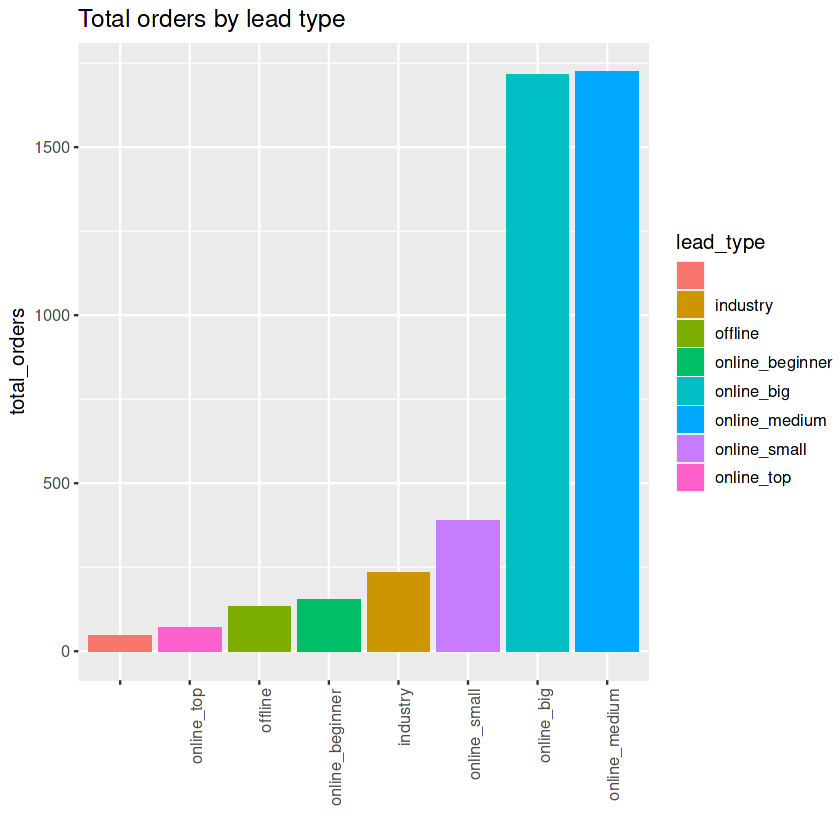

In [14]:
# Exploring shipments and deliveries made by Lead type of seller
by_lead <- temp3 %>%
    group_by(lead_type) %>%
    summarise(total_shipped_on_time = sum(shipped_on_time), total_delivered_on_time = sum(delivered_on_time), total_orders = n()) %>%
    mutate(percentage_shipped_on_time = round(total_shipped_on_time/total_orders * 100, 2)) %>%
    mutate(percentage_delivered_on_time = round(total_delivered_on_time/total_orders * 100, 2)) %>%
    mutate(percentage_of_total_deliveries_made = round(total_delivered_on_time/sum(total_orders) * 100, 2)) %>%
    arrange(desc(total_orders))

by_lead
ggplot(aes(x = reorder(lead_type, +total_orders), y = total_orders, fill = lead_type, xlab = ""), data = by_lead) +geom_bar(width = 0.9, stat= "identity", position = "dodge") +
theme(text = element_text(size=12), axis.text.x = element_text(angle=90, hjust=1)) +
labs(x = "") +
ggtitle("Total orders by lead type")

We see that Online_medium and Online_big dominate in terms of total number of orders.

lead_type,mean_delivery_time,total_orders
<chr>,<dbl>,<int>
online_big,11.115953,1715
,10.957021,47
online_beginner,10.860658,154
industry,9.674784,233
online_small,9.438208,389
offline,8.930992,133
online_medium,8.659683,1724
online_top,6.029571,71


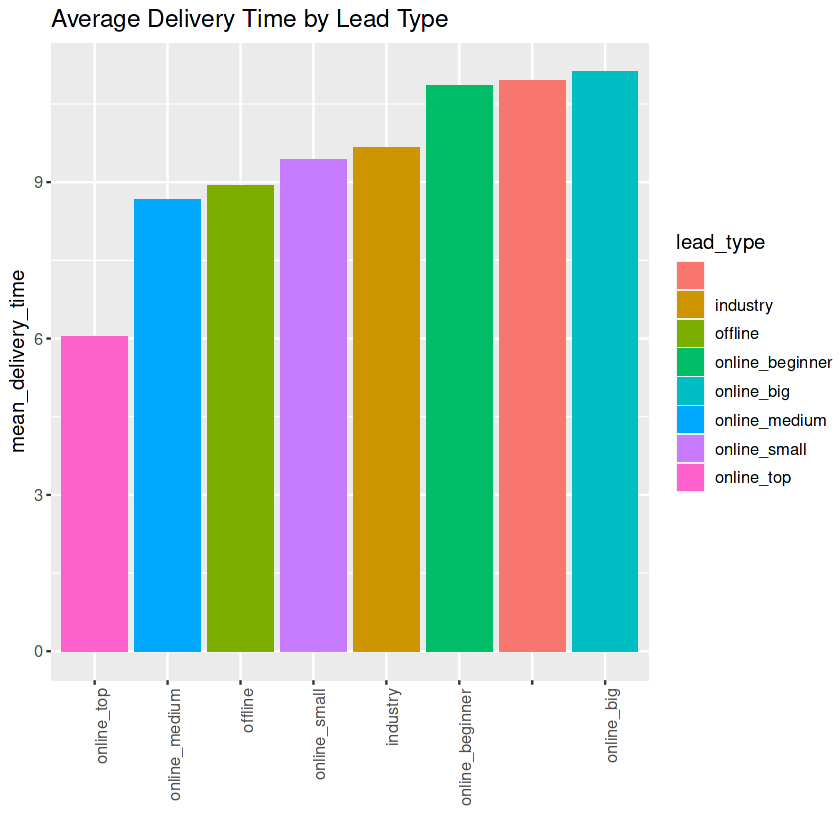

In [15]:
# Exploring shipping time by Lead type of seller
time_by_lead <- temp3 %>%
    group_by(lead_type) %>%
    summarise(mean_delivery_time = mean(delivery_time, na.rm=T), total_orders = n()) %>%
    #mutate(percentage_shipped_on_time = round(total_shipped_on_time/count * 100, 2)) %>%
    #mutate(percentage_delivered_on_time = round(total_delivered_on_time/count * 100, 2)) %>%
   # mutate(percentage_of_total_deliveries_made = round(total_delivered_on_time/sum(count) * 100, 2)) %>%
    arrange(desc(mean_delivery_time))

time_by_lead

ggplot(aes(x = reorder(lead_type, +mean_delivery_time), y = mean_delivery_time, fill = lead_type, xlab = ""), data = time_by_lead) +geom_bar(width = 0.9, stat= "identity", position = "dodge") +
theme(text = element_text(size=12), axis.text.x = element_text(angle=90, hjust=1)) +
labs(x = "") +
ggtitle("Average Delivery Time by Lead Type")

We see that in terms of delivery times, "Online_top" has the best performance of about 6 days on average from the time the order was placed to the time it was delivered to the customer. "Online_medium" is second best with an average of 8.7 days. "Online_big," "Online_beginner" and "Unknown" have the highest average delivery times of about 10~11 days per order, which is quite high.
To reduce our shipping times and improve customer satisfaction (and ratings), one strategy may be to attract more sellers from the "Online_top" category, while reducing reliance on "Online_big."

# What are the primary origins for our leads?

In [16]:
temp3 %>% group_by(origin) %>% summarise(Count = n()) %>% arrange(desc(Count)) 

origin,Count
<chr>,<int>
unknown,1264
paid_search,1230
organic_search,1193
social,391
direct_traffic,190
other,89
referral,69
email,22
,11


origin,total_shipped_on_time,total_delivered_on_time,total_orders,percentage_of_total_deliveries_made
<chr>,<dbl>,<dbl>,<int>,<dbl>
unknown,1133,1135,1264,25.41
paid_search,1109,1123,1230,25.15
organic_search,1139,1118,1193,25.03
social,355,361,391,8.08
direct_traffic,176,173,190,3.87
other,69,75,89,1.68
referral,68,65,69,1.46
email,21,21,22,0.47
,11,10,11,0.22


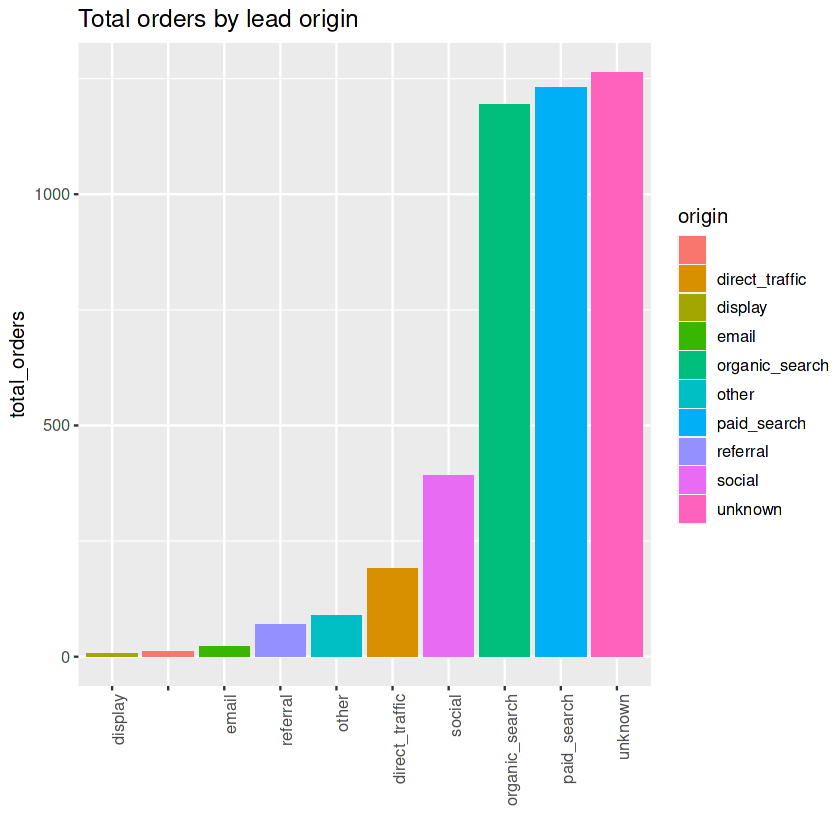

In [17]:
# Exploring shipments and deliveries made by lead origin in more detail
by_origin <- temp3 %>%
    group_by(origin) %>%
    summarise(total_shipped_on_time = sum(shipped_on_time), total_delivered_on_time = sum(delivered_on_time), total_orders = n()) %>%
    mutate(percentage_of_total_deliveries_made = round(total_delivered_on_time/sum(total_orders) * 100, 2)) %>%
    arrange(desc(percentage_of_total_deliveries_made))
by_origin
ggplot(aes(x = reorder(origin, +total_orders), y = total_orders, fill = origin, xlab = ""), data = by_origin) +geom_bar(stat= "identity", position = "dodge") +
theme(text = element_text(size=12), axis.text.x = element_text(angle=90, hjust=1)) +
labs(x = "") +
ggtitle("Total orders by lead origin")

"Unknown" is the lead source with the most orders. It would be advisable for Olist to track the origin of their leads more consistently, so that this data can be more useful to inform their marketing strategy. Out of the known lead sources, **"Paid_search"** and **"Organic_search"** account for the majority of orders with about 25% each. This validates the same finding from the Marketing Funnel dataset EDA above that didn't include actual order counts.

origin,mean_delivery_time,total_orders
<chr>,<dbl>,<int>
unknown,12.071289,1264
direct_traffic,10.075532,190
other,9.956163,89
referral,9.268209,69
paid_search,9.082313,1230
display,9.017143,7
social,8.570464,391
organic_search,8.545179,1193
email,8.322273,22


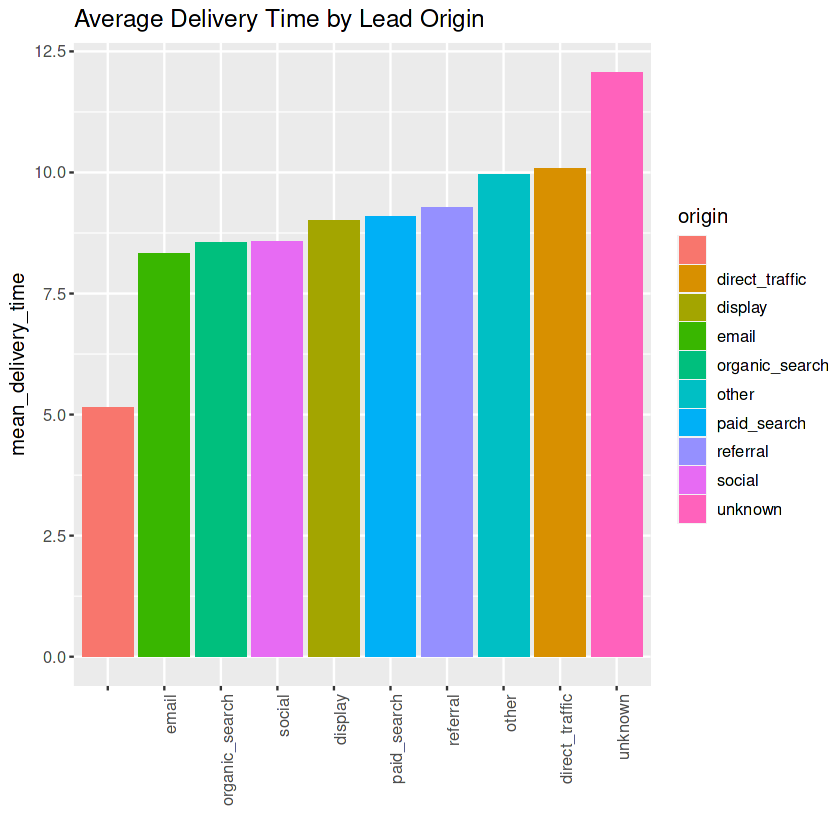

In [18]:
# Exploring shipping time by origin of seller
time_by_origin <- temp3 %>%
    group_by(origin) %>%
    summarise(mean_delivery_time = mean(delivery_time, na.rm=T), total_orders = n()) %>%
    arrange(desc(mean_delivery_time))
time_by_origin
ggplot(aes(x = reorder(origin, +mean_delivery_time), y = mean_delivery_time, fill = origin, xlab = ""), data = time_by_origin) +geom_bar(width = 0.9, stat= "identity", position = "dodge") +
theme(text = element_text(size=12), axis.text.x = element_text(angle=90, hjust=1)) +
labs(x = "") +
ggtitle("Average Delivery Time by Lead Origin")

The average delivery time by lead origin appears to be less varied and fairly consistent between **8-10 days** with the exception of leads that list no origin (i.e. origin == ""). This is interesting, because this particular subset shows the shortest delivery time of 5 days for a total of 11 orders. It would be useful to examine this further. Also, "Unknown" source shows the longest average delivery time of 12 days, which again should be enough reason to track the lead sources more accurately.

I now want to examine the close times of our representatives: how much time it took from first contact with a potential seller to the time they were signed up onto the Olist platform.

In [19]:
# Adding a column to original Marketing Funnel dataset
mkt_data <- mkt_data %>% mutate(lead_to_close = round(as.numeric(difftime(won_date, first_contact_date, units ="days")),2))
# Taking a look at average lead_to_close time per Sales Representative
close_times <- mkt_data %>%
    group_by(sr_id) %>%
    mutate(mean_close_time = round(mean(lead_to_close, na.rm=T)), 2) %>%
    mutate(total_deals_closed = n()) %>%
    distinct(sr_id, mean_close_time, total_deals_closed) %>%
    arrange(desc(mean_close_time))
cat('\n All sellers by descending average close time')
close_times
cat('\n Top 5 sellers by shortest average close time')
head(close_times %>% arrange(mean_close_time), 5)
# Average close time among all Sales Reps
cat('\n Average close time among all Sales Reps = ', round(mean(close_times$mean_close_time, na.rm=T)), 'days')


 All sellers by descending average close time

sr_id,mean_close_time,total_deals_closed
<chr>,<dbl>,<int>
6aa3b86a83d784b05f0e37e26b20860d,322,1
0a0fb2b07d841f84fb6714e35c723075,307,1
9749123c950bf8363ace42cb1c2d0815,234,7
9d12ef1a7eca3ec58c545c678af7869c,215,6
4b339f9567d060bcea4f5136b9f5949e,181,9
b90f87164b5f8c2cfa5c8572834dbe3f,176,1
34d40cdaf94010a1d05b0d6212f9e909,173,10
068066e24f0c643eb1d089c7dd20cd73,123,27
a8387c01a09e99ce014107505b92388c,97,26



 Top 5 sellers by shortest average close time

sr_id,mean_close_time,total_deals_closed
<chr>,<dbl>,<int>
9e4d1098a3b0f5da39b0bc48f9876645,17,24
fbf4aef3f6915dc0c3c97d6812522f6a,23,59
c638112b43f1d1b86dcabb0da720c901,23,36
060c0a26f19f4d66b42e0d8796688490,26,32
6565aa9ce3178a5caf6171827af3a9ba,26,74



 Average close time among all Sales Reps =  105 days

One important KPI to keep track of is the average lead_to_close days for each Sales Rep. SRs are there to close deals, and if they take a long time to close deals, unless they are closing big clients, they are underperforming. The top 5 Sales Representative close within 22 days on average, but our overall is 105 days. There are some clear inconsistencies here in terms of the close time of our reps that should be addressed. While it may be acceptable to have longer close times for very large and important sellers, the average time should be closer to the top performers

# What is the average sales conversion time by business type?


 Average close time by business type

business_type,average_time
<chr>,<dbl>
manufacturer,46.06959
other,254.46333
reseller,49.79279



 Total numbers of sellers by business type

business_type,Count
<chr>,<int>
reseller,587
manufacturer,242
other,3



 Information on the only three sellers listed as "Other" under business_type:

mql_id,first_contact_date,landing_page_id,origin,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue,lead_to_close
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
20fcec0873b39b4df3df34140d77d6e7,2018-01-12,22c29808c4f815213303f8933030604c,organic_search,cee3c487c56d29554a22d112af618301,084b6fbb10729ed4da8c3d3f5a3ae7c9,0a0fb2b07d841f84fb6714e35c723075,2018-11-14 18:04:19,other,other,cat,False,False,1-5,other,120,6000,306.75
9dde4d7713ae64986ab6f5c9f9cf94d3,2018-04-28,22c29808c4f815213303f8933030604c,organic_search,c33e6d3ad32fd5bec1b0f2522f668213,19f3cd308f1455b3fa09a282e0d496f4,a8387c01a09e99ce014107505b92388c,2018-11-09 20:06:38,other,other,cat,,,,other,100,500000,195.84
d5cb61eef98bd237e41bc2225263f823,2018-02-25,f017be4dbf86243af5c1ebed0cff36a2,paid_search,7e1f0755f1c75e301dfa37c21fd01efe,e4a6222cdb5b34375400904f03d8e6a5,34d40cdaf94010a1d05b0d6212f9e909,2018-11-12 19:17:25,other,other,"eagle, wolf",True,True,5-20,other,305,120000,260.80


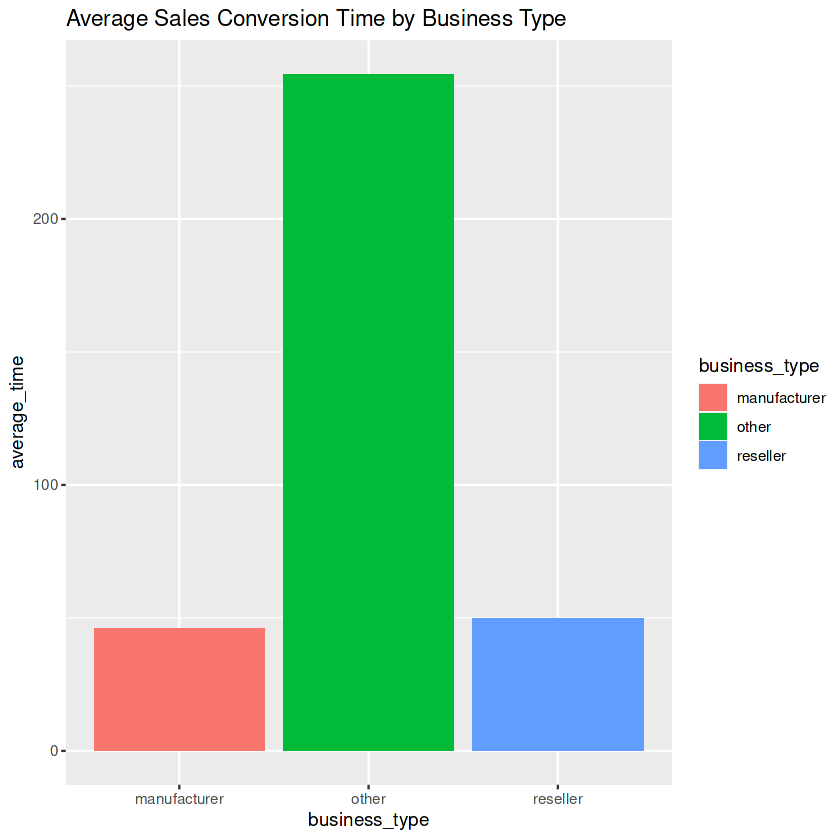

In [20]:
cat('\n Average close time by business type')
by_business <- mkt_data %>% filter (!business_type == "") %>% group_by(business_type) %>% summarise(average_time = mean(lead_to_close))
by_business
cat('\n Total numbers of sellers by business type')
mkt_data %>% filter (!business_type == "") %>% group_by(business_type) %>% summarise(Count = n()) %>% arrange(desc(Count))
ggplot(aes(x= business_type, y= average_time, fill = business_type), data = by_business) + geom_bar(stat ="identity") +
ggtitle("Average Sales Conversion Time by Business Type")
cat('\n Information on the only three sellers listed as "Other" under business_type:')
mkt_data %>% filter (business_type == "other") #%>% select(origin, lead_type) #%>% summarise(Count = n()) %>% arrange(desc(Count))


Manufacturer and Reseller show average close times fairly close to each other. However, "Other" is 200 days on average. While these businesses represent a very small number of the total (3 out of more than 800 total), this is still something that Olist may want to investigate further to pinpoint the exact reasons for this difference of *more than 150 days* on average.

Let's now look at the sellers by business type and their respective lead channels.

`summarise()` has grouped output by 'business_type'. You can override using the
`.groups` argument.


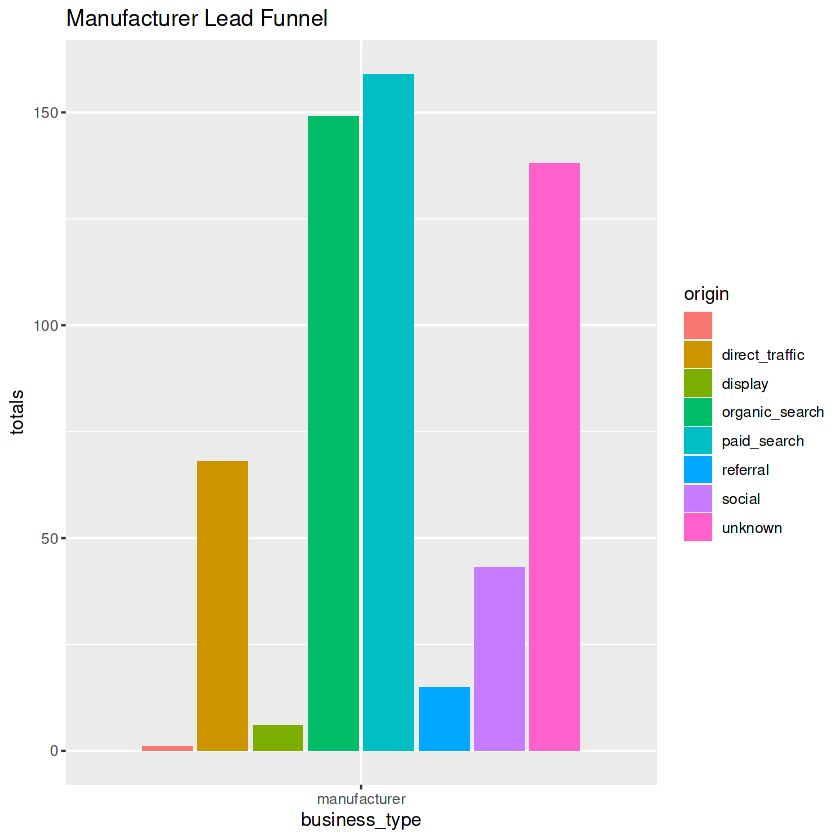

In [21]:
avgconversion <- temp3 %>% group_by(business_type,origin) %>% summarise(totals = n())
manufacturer <- avgconversion %>%
     select(business_type, origin, totals) %>%
     filter(business_type == "manufacturer")
ggplot(aes(x = business_type, y =totals, fill = origin), data = manufacturer) +geom_bar(stat= "identity", position = "dodge2") + ggtitle("Manufacturer Lead Funnel")


We see that for sellers who are manufacturers, the top lead sources are **organic** and **paid search**. Again, there are a lot of unknown leads, which needs to be looked into to better inform marketing. Direct traffic is the third major source of leads for manufacturers. Most likely, this is because customers are already familiar with these companies and their brands.

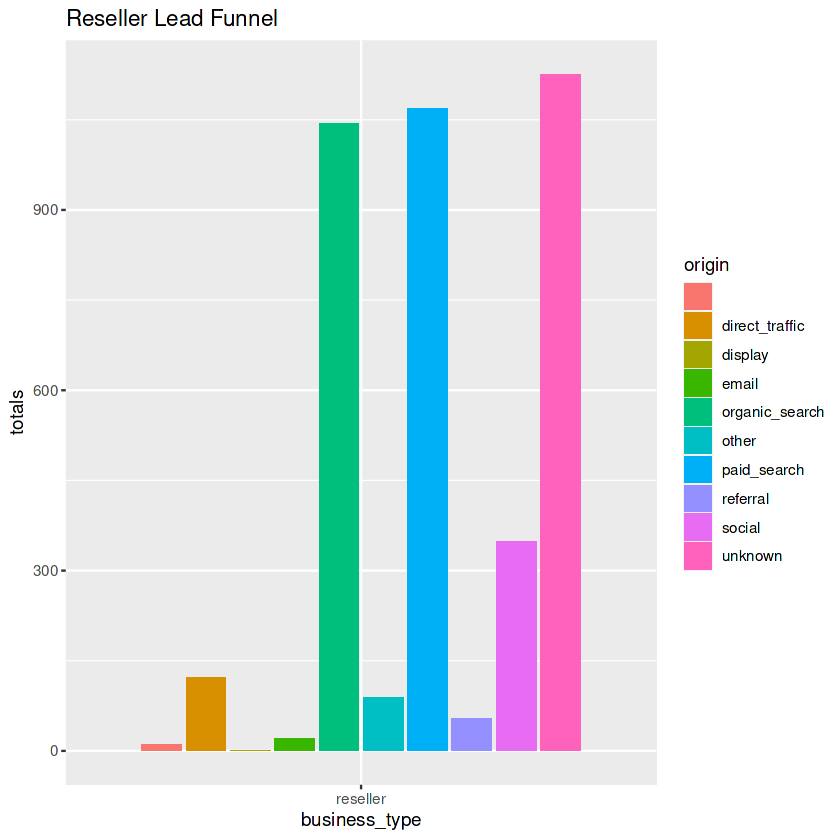

In [22]:
reseller <- avgconversion %>% select(business_type, origin, totals) %>% filter(business_type == "reseller")
ggplot(aes(x = business_type, y = totals, fill = origin), data = reseller) +geom_bar(stat= "identity", position = "dodge2") + ggtitle("Reseller Lead Funnel")

For resellers, the two main sources of leads are still organic and paid search. Interestingly, the third highest lead origin here is different -- **social** instead of direct traffic (ignoring "unknown"). This makes sense as resellers aren't likely to be as well-known or recognized by consumers as the actual product manufacturers. Thus, customers will first need to find these resellers through social media, email, blogs, search engines and other marketing channels.

The above two graphs show us the total breakdown of leads for the two major categories of sellers on the Olist platform: **Manufacturer** and **Reseller**. For both types of businesses, paid and organic search are already working effectively. Organic search doesn't cost US anything, which is great news. For paid search, we may want to compare the cost per lead with other channels, such as social and referrals. It may be more cost effective for Olist to pay for their leads through social media advertising, a referral program or email.

Secondly, the large swathes of "unknown" leads for both types of businesses really deserve our serious attention. As these leads represent the majority in both categories, we are missing out on a big opportunity to capitalize on this source (or multiple sources) of leads driven to our website. If anything, the Marketing team at Olist needs to first invest its time and resources into figuring out a way to track and classify these "unknown" leads. This may require a website redesign with better tracking functionality, as well as using more sophisticated web analytics tools.